In [1]:
"""
Aim: validation of immune and stallete cells
Author: Yike Xie
Date: 3rd-Apr-2025 
"""

'\nAim: validation of immune and stallete cells\nAuthor: Yike Xie\nDate: 3rd-Apr-2025 \n'

In [2]:
import utils

import scanpy as sc
import anndata as ad

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
metadata = pd.read_csv('../tables/DESeq/pseudo_bulk_sum/metadata.tsv', sep='\t', index_col=0)
from matplotlib.patches import Patch

# load data

In [9]:
# load data
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')
adata.raw = adata

In [10]:
utils.normalizedata(adata, log1p=True)

AnnData object with n_obs × n_vars = 57935 × 38560
    obs: 'sample', 'doublet_score', 'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 'HbA1c (%)', 'HbA1c', 'Age', 'CIT (hours)', 'Cohort', 'RIN', 'Nuclei isolation', 'group', 'cell_type', 'cell_subtype', 'cst1', 'cst2'
    var: 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cst1_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

# Rename (20250428)

In [ ]:
# load data
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

- Rename back `Neurons` to `Schwann` cells
- keep both `Inflam_ductal1` and `Inflam_ductal2`
- `Acinar_1` --> `Signaling_acinar`
- `Acinar_2` --> `Intermediate_acinar`
- `Acinar_3` --> `High_enzyme_acinar`
- `Pancreatic_resident_macrophages` --> `Macrophages`
- `CD27-_IgA+_plasmablasts` --> `Plasmablasts`
- `Pancreatc_persistent_memory_like_T_cells` --> `T_cells`

In [ ]:
adata.obs['cell_type'] = adata.obs['cell_type'].cat.rename_categories({
    'Neurons': 'Schwann'
})

In [ ]:
adata.obs['cell_type'].value_counts()

cell_type
Acinar         36560
Ductal         15956
Endocrine       2104
Stellate        1667
Immune           818
Endothelial      689
Schwann           64
Name: count, dtype: int64

In [ ]:
adata.obs['cell_subtype'] = adata.obs['cst2']
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].cat.rename_categories({
    'Neurons': 'Schwann',
    'Acinar_1': 'Signaling_acinar',
    'Acinar_2': 'Intermediate_acinar',
    'Acinar_3': 'High_enzyme_acinar',
    'Pancreatic_resident_macrophages': 'Macrophages',
    'CD27-_IgA+_plasmablasts': 'Plasmablasts',
    'Pancreatic_persistent_memory_like_T_cells': 'T_cells'
    })

adata.obs['cell_subtype'] = adata.obs['cell_subtype'].cat.add_categories(['Endothelial'])

adata.obs.loc[adata.obs['cell_subtype'].isin([
    'Venous_ECs', 
    'Capillary_ECs', 
    'Arterial_ECs', 
    'Lymphatic_ECs']), 'cell_subtype'] = 'Endothelial'
    
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].cat.remove_unused_categories()

In [ ]:
adata.obs['cell_subtype'].value_counts()

cell_subtype
Signaling_acinar       25515
Intermediate_acinar    10851
Basel_ductal           10069
Inflam_ductal_2         2962
Inflam_ductal_1         2753
Activated_stellates     1487
β                       1171
α                        721
Endothelial              689
Macrophages              627
High_enzyme_acinar       271
Quiescent_stellates      180
MUC5B+_ductal            172
T_cells                  161
δ                        116
γ                         96
Schwann                   64
Mast_cells                17
Plasmablasts              13
Name: count, dtype: int64

In [ ]:
adata.obs = adata.obs.drop(columns=['cst1'])
adata.obs = adata.obs.rename({
    'cst2': 'cell_subtype1'}, axis=1)
adata.obs['cell_subtype2'] = adata.obs['cell_subtype1']

adata.obs['cell_subtype1'] = adata.obs['cell_subtype1'].cat.rename_categories({
    'Neurons': 'Schwann',
    'Acinar_1': 'Signaling_acinar',
    'Acinar_2': 'Intermediate_acinar',
    'Acinar_3': 'High_enzyme_acinar',
    'Pancreatic_resident_macrophages': 'Macrophages',
    'CD27-_IgA+_plasmablasts': 'Plasmablasts',
    'Pancreatic_persistent_memory_like_T_cells': 'T_cells'
    })

adata.obs['cell_subtype2'] = adata.obs['cell_subtype2'].cat.rename_categories({
    'Neurons': 'Schwann',
    'Acinar_1': 'Signaling_acinar',
    'Acinar_2': 'Intermediate_acinar',
    'Acinar_3': 'High_enzyme_acinar',
    })

adata.obs['cell_subtype1'] = adata.obs['cell_subtype1'].cat.remove_unused_categories()
adata.obs['cell_subtype2'] = adata.obs['cell_subtype2'].cat.remove_unused_categories()

In [ ]:
adata.obs['cell_subtype1'].value_counts()

cell_subtype1
Signaling_acinar       25515
Intermediate_acinar    10851
Basel_ductal           10069
Inflam_ductal_2         2962
Inflam_ductal_1         2753
Activated_stellates     1487
β                       1171
α                        721
Macrophages              627
Capillary_ECs            454
High_enzyme_acinar       271
Quiescent_stellates      180
MUC5B+_ductal            172
T_cells                  161
Venous_ECs               128
δ                        116
γ                         96
Arterial_ECs              78
Schwann                   64
Lymphatic_ECs             29
Mast_cells                17
Plasmablasts              13
Name: count, dtype: int64

In [ ]:
adata.obs['cell_subtype2'].value_counts()

cell_subtype2
Signaling_acinar                             25515
Intermediate_acinar                          10851
Basel_ductal                                 10069
Inflam_ductal_2                               2962
Inflam_ductal_1                               2753
Activated_stellates                           1487
β                                             1171
α                                              721
Pancreatic_resident_macrophages                627
Capillary_ECs                                  454
High_enzyme_acinar                             271
Quiescent_stellates                            180
MUC5B+_ductal                                  172
Pancreatic_persistent_memory_like_T_cells      161
Venous_ECs                                     128
δ                                              116
γ                                               96
Arterial_ECs                                    78
Schwann                                         64
Lymphatic_ECs    

- Change the `group` of donor `C11` to `T2D`
- Change the `group` of donors `U6`, `C4`, `U9`, and `U4` to `Pre-T2D`

In [ ]:
adata.obs['group'] = adata.obs['group'].cat.add_categories('Pre-T2D')

In [ ]:
adata.obs.loc[adata.obs['sample'] == 'C11', 'group'] = 'T2D'

adata.obs.loc[adata.obs['sample'].isin(['C4', 'U4', 'U6', 'U9']), 
              'group'] = 'Pre_T2D'

In [ ]:
adata.obs['group'] = adata.obs['group'].cat.rename_categories({
    'ND - Lean': 'ND-Lean',
    'ND - Obese': 'ND-Obese'
})

In [ ]:
adata.obs['group'].value_counts()

group
ND-Lean     27666
ND-Obese    12725
T2D         11631
Pre-T2D      5413
T1D           500
Name: count, dtype: int64

In [ ]:
samples = adata.obs['sample'].cat.categories.tolist()

metadata = pd.DataFrame([], index=samples, columns=adata.obs.columns[1:])
for sample in samples:
    metadata.loc[sample] = adata[adata.obs['sample'] == sample].copy().obs.iloc[0][1:]
    
metadata.to_csv('../tables/DESeq/pseudo_bulk_sum/metadata.tsv', sep='\t')

In [ ]:
adata.obs['group'] = adata.obs['group'].cat.reorder_categories(
    ['ND-Lean', 'ND-Obese', 'T1D', 'Pre-T2D', 'T2D']
)

In [ ]:
adata.obs['cell_type']

bc_wells
38_02_01         Acinar
38_02_04         Acinar
38_02_15         Acinar
38_02_26    Endothelial
38_02_54    Endothelial
               ...     
44_74_20         Acinar
44_74_27         Acinar
44_80_06         Acinar
44_83_57         Acinar
44_84_83         Ductal
Name: cell_type, Length: 57935, dtype: category
Categories (7, object): ['Endocrine' < 'Acinar' < 'Ductal' < 'Endothelial' < 'Immune' < 'Stellate' < 'Schwann']

In [ ]:
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].cat.reorder_categories(
    ['α', 'β', 'γ', 'δ',
     'Signaling_acinar', 'Intermediate_acinar', 'High_enzyme_acinar',
     'Basel_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
     'Endothelial',
     'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
     'Activated_stellates', 'Quiescent_stellates', 
     'Schwann',
     ]
)

In [ ]:
adata.obs['cell_subtype1'] = adata.obs['cell_subtype1'].cat.reorder_categories(
    ['α', 'β', 'γ', 'δ',
     'Signaling_acinar', 'Intermediate_acinar', 'High_enzyme_acinar',
     'Basel_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
     'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs',
     'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
     'Activated_stellates', 'Quiescent_stellates', 
     'Schwann',
     ]
)

Index(['Basel_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
       'Signaling_acinar', 'Intermediate_acinar', 'High_enzyme_acinar',
       'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells', 'Schwann',
       'Capillary_ECs', 'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs',
       'Activated_stellates', 'Quiescent_stellates', 'α', 'β', 'γ', 'δ'],
      dtype='object')

In [ ]:
adata.obs['cell_subtype2'] = adata.obs['cell_subtype2'].cat.reorder_categories(
    ['α', 'β', 'γ', 'δ',
     'Signaling_acinar', 'Intermediate_acinar', 'High_enzyme_acinar',
     'Basel_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
     'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs',
     'Pancreatic_resident_macrophages', 'CD27-_IgA+_plasmablasts',
     'Pancreatic_persistent_memory_like_T_cells', 'Mast_cells',
     'Activated_stellates', 'Quiescent_stellates', 
     'Schwann',
     ]
)

In [ ]:
adata.write('../data/parse_snRNA_annotated_YK_raw.h5ad')

# Remove doublets (20250702)

In [ ]:
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

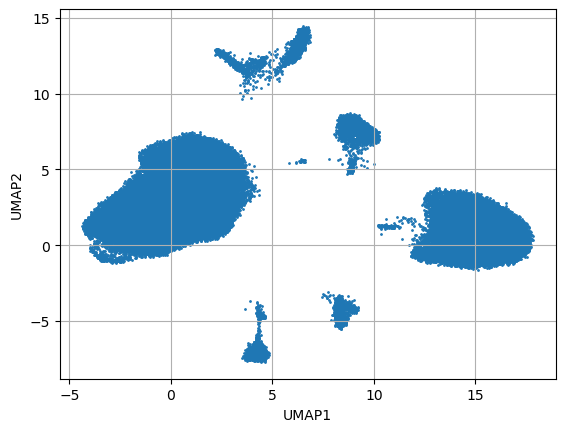

In [ ]:
fig, ax = plt.subplots()
ax.scatter(adata.obsm['X_umap'][:, 0], adata.obsm['X_umap'][:, 1], s=1)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax.grid()
plt.show()

In [ ]:
umap = adata.obsm['X_umap']
x, y = umap[:, 0], umap[:, 1]

# Define bounding box of doublets in ductal and endothelial cells
xmin, xmax = 6, 15
ymin, ymax = -5, 5

mask = (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax)

In [ ]:
adata.obs['Doublets'] = 'no'
adata.obs.loc[
    (adata.obs['cell_subtype'].isin(['Basal_acinar']))
    & (mask),
    'Doublets'] = 'yes'

In [ ]:
adata.obs['Doublets'].value_counts()

Doublets
no     57858
yes       77
Name: count, dtype: int64

In [ ]:
adata.write('../data/parse_snRNA_annotated_YK_raw.h5ad')

# Further rename acinar and ductal subtypes

In [ ]:
# load data
adata = sc.read_h5ad('../../data/parse_snRNA_annotated_YK_raw.h5ad')
adata = adata[adata.obs['Doublets'] == 'no'].copy()

# edit the name of acinar cell subtypes refering to the paper: DOI: 10.1101/2025.10.01.679230
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].astype(str)

mask1 = adata.obs['cell_type'] == 'Acinar'
adata.obs.loc[mask1, 'cell_subtype'] = adata.obs.loc[mask1, 'cell_subtype2']

mask2 = adata.obs['cell_type'] == 'Endothelial'
adata.obs.loc[mask2, 'cell_subtype'] = adata.obs.loc[mask2, 'cell_subtype1']

# Fix cell_type replacement safely
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].astype(str).replace({
    'Signaling_acinar': 'Idling_acinar',
    'Intermediate_acinar': 'Secretory_acinar',
    'High_enzyme_acinar': 'REG+_acinar',
    'Basal_ductal': 'Canonical_ductal'
})

desired_cst_order = [
    'α', 'β', 'γ', 'δ', 'Idling_acinar', 'Secretory_acinar', 'REG+_acinar',
    'Canonical_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
    'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs',                   
    'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
    'Activated_stellates', 'Quiescent_stellates', 'Schwann'
]
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].astype('category')
adata.obs['cell_subtype'] = (
    adata.obs['cell_subtype']
    .cat.set_categories(desired_cst_order, ordered=True)
)

adata.write('../../data/parse_snRNA_annotated_YK_raw.h5ad')